In [ ]:
!pip install dtreeviz

In [1]:
%config InlineBackend.figure_format = 'retina' # Make visualizations look good
# %config InlineBackend.figure_format = 'svg'
%matplotlib inline

In [10]:
from spockflow.components.treelite import Tree
from spockflow.components.treelite.core import CompiledTreeliteTree, OutputEncoding
import json
import treelite.sklearn
import numpy as np
import pandas as pd
import dtreeviz

In [11]:
with open("source_dir/config.json") as fp:
    tree = Tree.model_validate_json(fp.read())

In [12]:
node_id_mapping, leaf_nodes = CompiledTreeliteTree._get_node_id_mapping(tree.nodes)
root_nodes = CompiledTreeliteTree._identify_independent_tree_roots(tree.nodes)
trees = [
    CompiledTreeliteTree._build_treelite_tree(
        root_nodes=[rn],
        tree=tree,
        node_id_mapping=node_id_mapping,
        output_encoding=OutputEncoding.ONE_HOT,
    ).commit()
    for rn in root_nodes
]

In [13]:
sklearn_tree = treelite.sklearn.export_model(trees[0])

In [14]:
with open("data.json") as fp:
    input_data = pd.json_normalize(json.load(fp))
input_data
input_data["cls"] = [0, 0, 0, 0, 1, 0, 1, 1]
input_data

,AFDelinquentAmount,AFDaysArrears,AFMinPaymentDue,cls
0,-60,-1,0,0
1,100,-1,0,0
2,-60,1,0,0
3,100,1,0,0
4,-60,-1,1,1
5,100,-1,1,0
6,-60,1,1,1
7,100,1,1,1


In [15]:
sklearn_tree.estimators_[0].classes_ = np.arange(2, dtype=np.int32)

In [16]:
viz_model = dtreeviz.model(
    sklearn_tree.estimators_[0],
    X_train=input_data[tree.features],
    y_train=input_data["cls"],
    feature_names=tree.features,
    target_name="cls",
    class_names=["Positive", "Negative"],
)

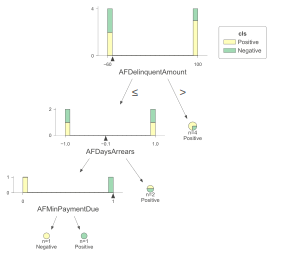

In [17]:
viz_model.view(scale=0.8)